<a href="https://colab.research.google.com/github/umanahekeobong-cell/Fresh-Apple-vs-Formalin-mixed-Apple/blob/main/23_EG_EE_097_L10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Project Setup & Data Preparation

### Dependencies Installation

In [1]:
import zipfile
import os

# Specify the path to your zipped file
zipped_file_path = '/content/drive/MyDrive/apple1.zip'  # Replace with your file path

# Specify the directory where you want to extract the contents
extraction_directory = './extracted_applecontent/' # Replace or confirm your desired directory

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_directory, exist_ok=True)

try:
    with zipfile.ZipFile(zipped_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_directory)
    print(f"Successfully unzipped '{zipped_file_path}' to '{extraction_directory}'")
except FileNotFoundError:
    print(f"Error: The file '{zipped_file_path}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: '{zipped_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully unzipped '/content/drive/MyDrive/apple1.zip' to './extracted_applecontent/'


In [2]:
!pip show matplotlib seaborn scikit-learn tensorflow

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

### Data Unzipping and Initial Setup

In [3]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')

TensorFlow version : 2.20.0
Random seed set to : 42


In [4]:
results_dir = "results/lab7/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

In [5]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')

Thu Jul 30 23:50:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import os
import shutil
from pathlib import Path

base_input = "/content/extracted_applecontent/Apple" # Updated path to point to the extracted dataset
base_output = "/content/datasets/applerenamed/" # Changed to an absolute path
base_path = Path(base_output)
base_path

PosixPath('/content/datasets/applerenamed')

### Dataset Splitting and Directory Setup

In [7]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define split ratios (using global variables if available, or define locally)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Ensure output base directories for splits exist
output_train_dir = os.path.join(base_output, 'train')
output_val_dir = os.path.join(base_output, 'val')
output_test_dir = os.path.join(base_output, 'test')

# --- Clear existing output directories before populating ---
# This ensures a clean slate for each run of the splitting process
if os.path.exists(output_train_dir):
    shutil.rmtree(output_train_dir)
if os.path.exists(output_val_dir):
    shutil.rmtree(output_val_dir)
if os.path.exists(output_test_dir):
    shutil.rmtree(output_test_dir)

os.makedirs(output_train_dir, exist_ok=True)
os.makedirs(output_val_dir, exist_ok=True)
os.makedirs(output_test_dir, exist_ok=True)

# Determine the 'plant' name from the base_input path, e.g., 'Apple'
# rstrip for robustness with trailing slashes
plant_name = os.path.basename(base_input.rstrip('/'))

# Iterate through disease categories within the base_input (e.g., 'Formalin-mixed', 'Fresh', 'Rotten')
for disease_category in os.listdir(base_input):
    # Skip 'Rotten' category as per user request
    if disease_category == 'Rotten':
        print(f"Skipping 'Rotten' category as requested.")
        continue

    current_disease_path = os.path.join(base_input, disease_category)

    # Skip if it's not a directory or a system file like desktop.ini
    if not os.path.isdir(current_disease_path) or disease_category.startswith('.'):
        continue

    # Get all image file paths in the current disease category
    all_files = [os.path.join(current_disease_path, f) for f in os.listdir(current_disease_path)
                 if os.path.isfile(os.path.join(current_disease_path, f)) and not f.startswith('.')]

    if not all_files:
        print(f"No files found in {current_disease_path}. Skipping.")
        continue

    # Create the combined class name for the output directories (e.g., 'Apple_Formalin-mixed')
    class_name = f"{plant_name}_{disease_category}"

    # First split: train and temporary (val + test)
    train_files, temp_files = train_test_split(all_files, train_size=train_ratio, random_state=SEED, shuffle=True)

    # Second split: validate and test from temporary files
    # Calculate adjusted test_size for the second split: test_ratio / (val_ratio + test_ratio)
    # This ensures the ratios are applied correctly to the remaining data
    adjusted_test_size = test_ratio / (val_ratio + test_ratio)
    val_files, test_files = train_test_split(temp_files, test_size=adjusted_test_size, random_state=SEED, shuffle=True)

    # Create destination directories for the current class within each split
    dst_train_class_dir = os.path.join(output_train_dir, class_name)
    dst_val_class_dir = os.path.join(output_val_dir, class_name)
    dst_test_class_dir = os.path.join(output_test_dir, class_name)

    os.makedirs(dst_train_class_dir, exist_ok=True)
    os.makedirs(dst_val_class_dir, exist_ok=True)
    os.makedirs(dst_test_class_dir, exist_ok=True)

    # Copy files to their respective split directories
    for file_path in train_files:
        shutil.copy(file_path, dst_train_class_dir)
    for file_path in val_files:
        shutil.copy(file_path, dst_val_class_dir)
    for file_path in test_files:
        shutil.copy(file_path, dst_test_class_dir)

    print(f"Processed '{class_name}': Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)} files.")

print("Data splitting and copying complete!")

Processed 'Apple_Formalin-mixed': Train=450, Val=97, Test=97 files.
Skipping 'Rotten' category as requested.
Processed 'Apple_Fresh': Train=536, Val=115, Test=115 files.
Data splitting and copying complete!


In [8]:
from pathlib import Path

BASE_DIR = Path(base_output)
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'

print(f"Base directory: {BASE_DIR}")
print(f"Train directory: {train_dir}")
print(f"Validation directory: {val_dir}")
print(f"Test directory: {test_dir}")

Base directory: /content/datasets/applerenamed
Train directory: /content/datasets/applerenamed/train
Validation directory: /content/datasets/applerenamed/val
Test directory: /content/datasets/applerenamed/test


In [9]:
for split, d in [('train', train_dir), ('val', val_dir), ('test',
test_dir)]:
    exists = d.exists()
    count = sum(1 for _ in d.rglob('*.jpg')) + sum(1 for _ in
            d.rglob('*.png')) if exists else 0
print(f'{split:>5} dir exists={exists} images≈{count}')

 test dir exists=True images≈203


In [10]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50 # EarlyStopping will stop earlier when converged
LR = 1e-3 # Initial learning rate for the CNN from scratch
print(f'Image size : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size : 128 x 128
Batch size : 64
Max epochs : 50
Learning rate: 0.001


### Dataset Loading and Augmentation

In [11]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
train_dir,image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE,seed=SEED, shuffle=True,
)

Found 985 files belonging to 2 classes.


In [12]:
import tensorflow as tf

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
    # Setting shuffle=False for validation and test datasets is often preferred for reproducibility
)

print(f"Validation dataset loaded from: {val_dir}")
print(f"Validation dataset class names: {val_dataset.class_names}")

Found 211 files belonging to 2 classes.
Validation dataset loaded from: /content/datasets/applerenamed/val
Validation dataset class names: ['Apple_Formalin-mixed', 'Apple_Fresh']


In [13]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE, seed=SEED,shuffle=False,
)

Found 212 files belonging to 2 classes.


In [14]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['Apple_Formalin-mixed', 'Apple_Fresh']


In [15]:
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

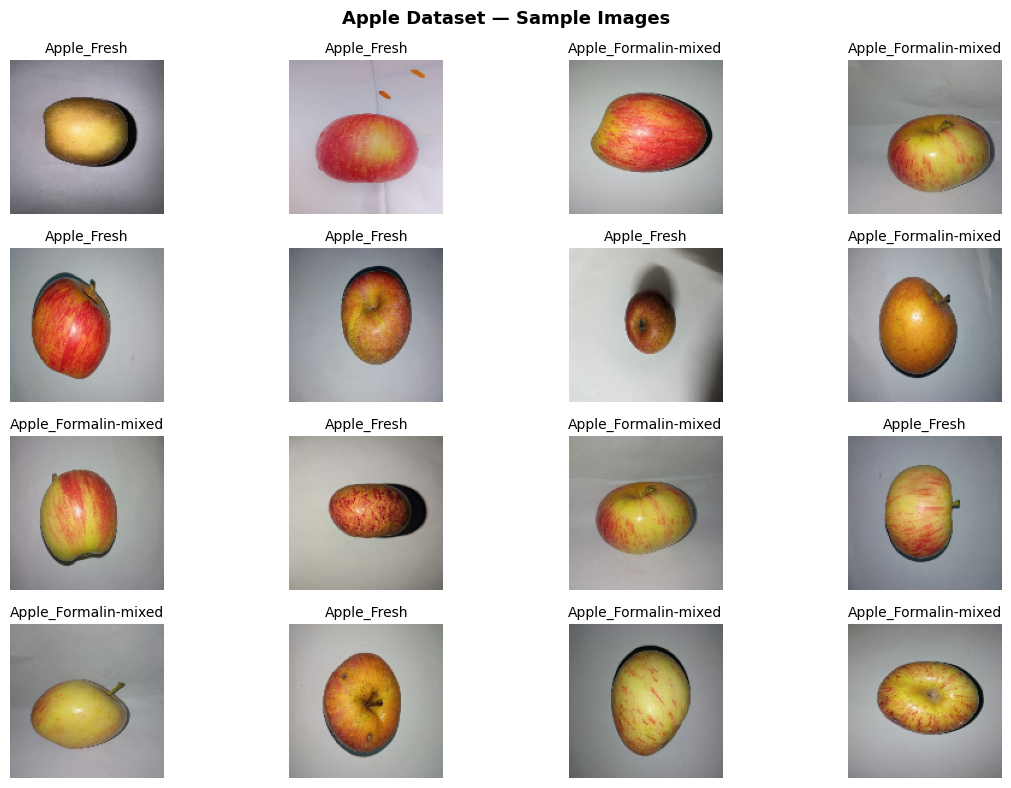

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')
plt.suptitle('Apple Dataset — Sample Images', fontsize=13, fontweight='bold') # Changed title to be more relevant
plt.tight_layout()
plt.savefig('lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (
train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))
val_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))
print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


In [18]:
data_augmentation = tf.keras.Sequential([
tf.keras.layers.RandomFlip('horizontal'),
tf.keras.layers.RandomRotation(0.2),
tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

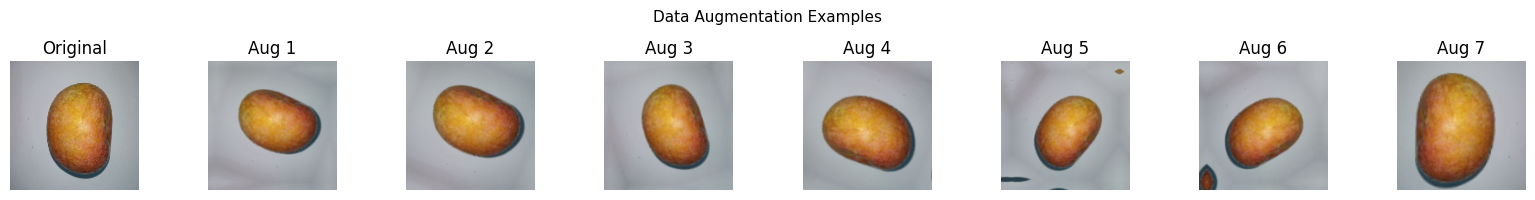

In [19]:
for images, _ in train_dataset.take(1):
    sample = images[0:1] # shape (1, 224, 224, 3)
    break
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 8):
    aug_img = data_augmentation(sample,
                              training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig('lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Model Training & Evaluation

### Utility Functions for Model Training

In [20]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,
             linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,
             linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results_dir + f'lab8_{title.lower().replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model',
                 results_dir='./'):
    """Evaluate a multiclass classification model."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 9, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(
        results_dir + f'lab8_{title.lower().replace(" ", "_")}_confusion.png',
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()

    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


### Custom CNN Model Training

In [21]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes
def build_custom_cnn(input_shape, augmentation):
    """
    A three-block CNN built entirely from scratch.
    Filters double each block (32 >> 64 >> 128) following a standard design
    pattern.
    Augmentation is embedded inside the model so it runs automatically during
    training.
    """
    inputs = tf.keras.Input(shape=input_shape)
    # Augmentation (active only during training)
    x = augmentation(inputs)
    # Normalise pixel values from [0, 255] to [0, 1]
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    # Binary output: sigmoid → probability of class 1 (dogs)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [22]:
cnn_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)

In [23]:
cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset,epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 412ms/step - accuracy: 0.6142 - loss: 0.7095 - val_accuracy: 0.4550 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/step - accuracy: 0.6751 - loss: 0.5776 - val_accuracy: 0.4550 - val_loss: 0.9421 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - accuracy: 0.7005 - loss: 0.5372 - val_accuracy: 0.4550 - val_loss: 1.0878 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.7401 - loss: 0.5037 - val_accuracy: 0.4550 - val_loss: 1.4695 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7167 - loss: 0.5036
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.7320 - loss: 0.4956 - val_accuracy: 0.4550 - val_loss: 1.3316 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.7624 - loss: 0.4553 -

In [24]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.7174
val_accuracy: 0.4550


In [25]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.7174
val_accuracy: 0.4550


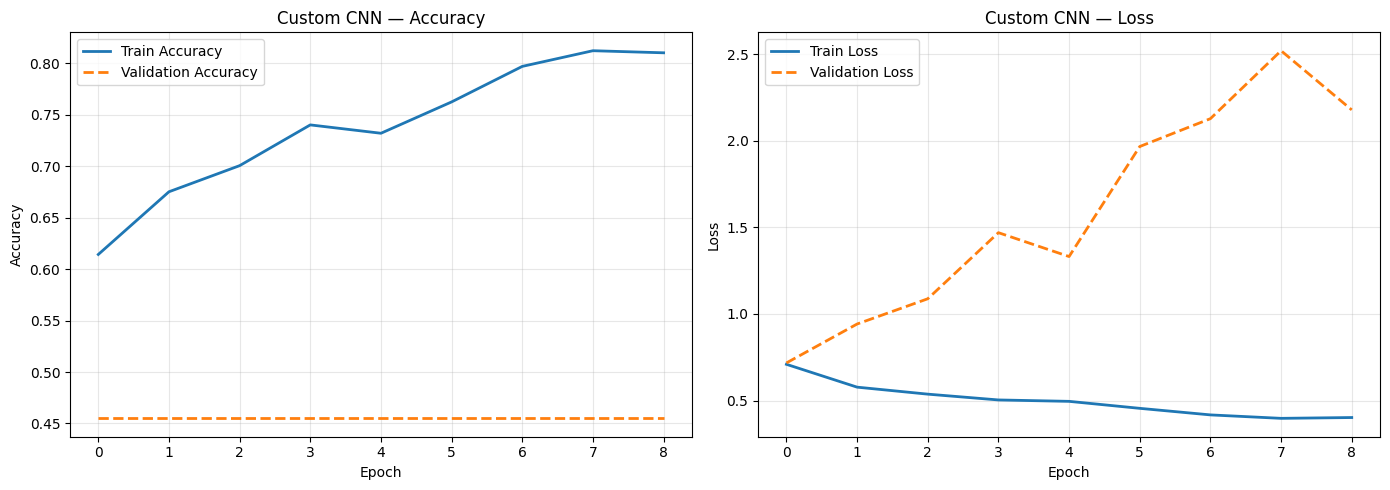

In [26]:
plot_learning_curves(cnn_history, 'Custom CNN')


Custom CNN
Accuracy : 0.4575
Precision : 0.2093
Recall : 0.4575
F1-Score : 0.2873

Classification Report:
                      precision    recall  f1-score   support

Apple_Formalin-mixed     0.4575    1.0000    0.6278        97
         Apple_Fresh     0.0000    0.0000    0.0000       115

            accuracy                         0.4575       212
           macro avg     0.2288    0.5000    0.3139       212
        weighted avg     0.2093    0.4575    0.2873       212



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

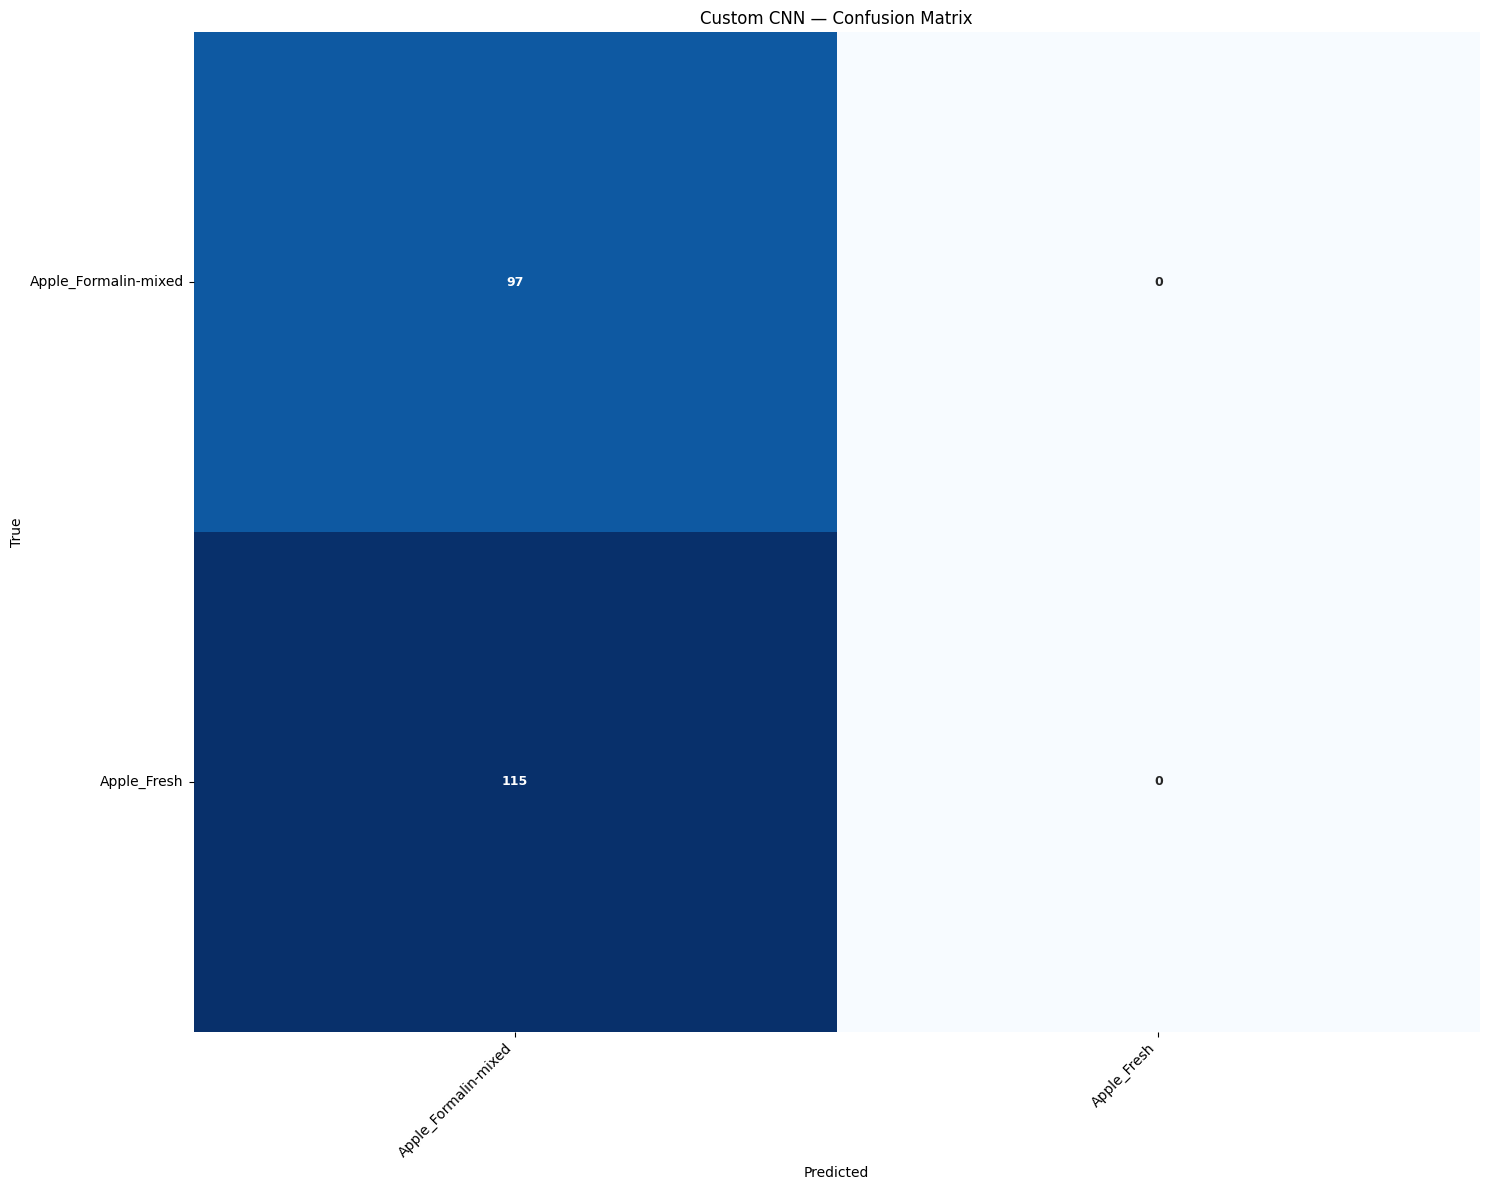

In [27]:
cnn_test_acc = evaluate_model(cnn_model, test_dataset,
class_names, 'Custom CNN')

### Transfer Learning (MobileNetV3) Model Training

In [28]:
def build_transfer_model(input_shape, augmentation,
                         backbone='mobilenetv3small'):
    """
    Feature extraction model:
    1. Augment input (training only)
    2. Preprocess for MobileNetV3 (scales to [-1, 1])
    3. Frozen MobileNetV3Small backbone (no top)
    4. GlobalAveragePooling2D
    5. Dense classification head
    """
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    else:
        # Fallback: MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'

    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False

    print(f'Base model : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if \
                                  l.trainable)} / {len(base_model.layers)}')

    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]
    x = base_model(x, training=False) # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation,
                                            backbone='mobilenetv3small')
tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [29]:
TL_LR = 1e-4 # Lower LR for transfer learning head
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
tl_history = tl_model.fit(
train_dataset,
validation_data=val_dataset,
epochs=EPOCHS,
callbacks=make_callbacks('tl_feature_extraction'),
verbose=1,
)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - accuracy: 0.4792 - loss: 0.8062 - val_accuracy: 0.5687 - val_loss: 0.6894 - learning_rate: 1.0000e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5320 - loss: 0.7326 - val_accuracy: 0.6351 - val_loss: 0.6415 - learning_rate: 1.0000e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5675 - loss: 0.6875 - val_accuracy: 0.6872 - val_loss: 0.6076 - learning_rate: 1.0000e-04
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6325 - loss: 0.6461 - val_accuracy: 0.7014 - val_loss: 0.5818 - learning_rate: 1.0000e-04
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6548 - loss: 0.6196 - val_accuracy: 0.7346 - val_loss: 0.5626 - learning_rate: 1.0000e-04
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6558 - loss: 0.5943 - val_accuracy: 0.7251 - val_loss: 0.5474 - learning_rate: 1.0000e-04
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.696

MobileNetV3 TL -> val_loss: 0.4380
MobileNetV3 TL -> val_accuracy: 0.7773


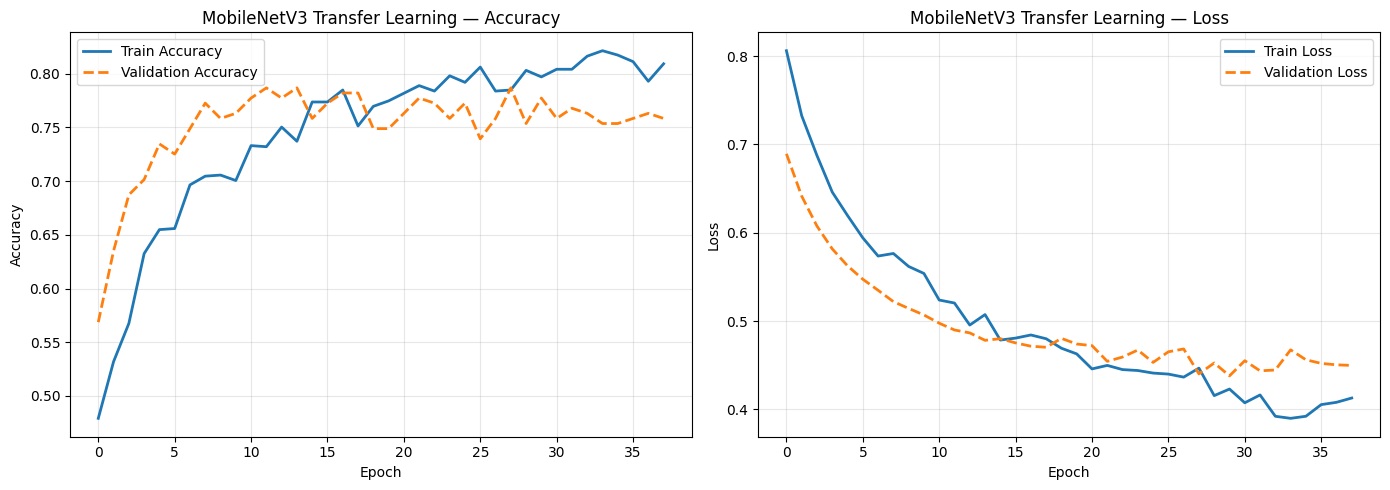

In [30]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')


MobileNetV3 Transfer
Accuracy : 0.7877
Precision : 0.7942
Recall : 0.7877
F1-Score : 0.7843

Classification Report:
                      precision    recall  f1-score   support

Apple_Formalin-mixed     0.8333    0.6701    0.7429        97
         Apple_Fresh     0.7612    0.8870    0.8193       115

            accuracy                         0.7877       212
           macro avg     0.7973    0.7785    0.7811       212
        weighted avg     0.7942    0.7877    0.7843       212



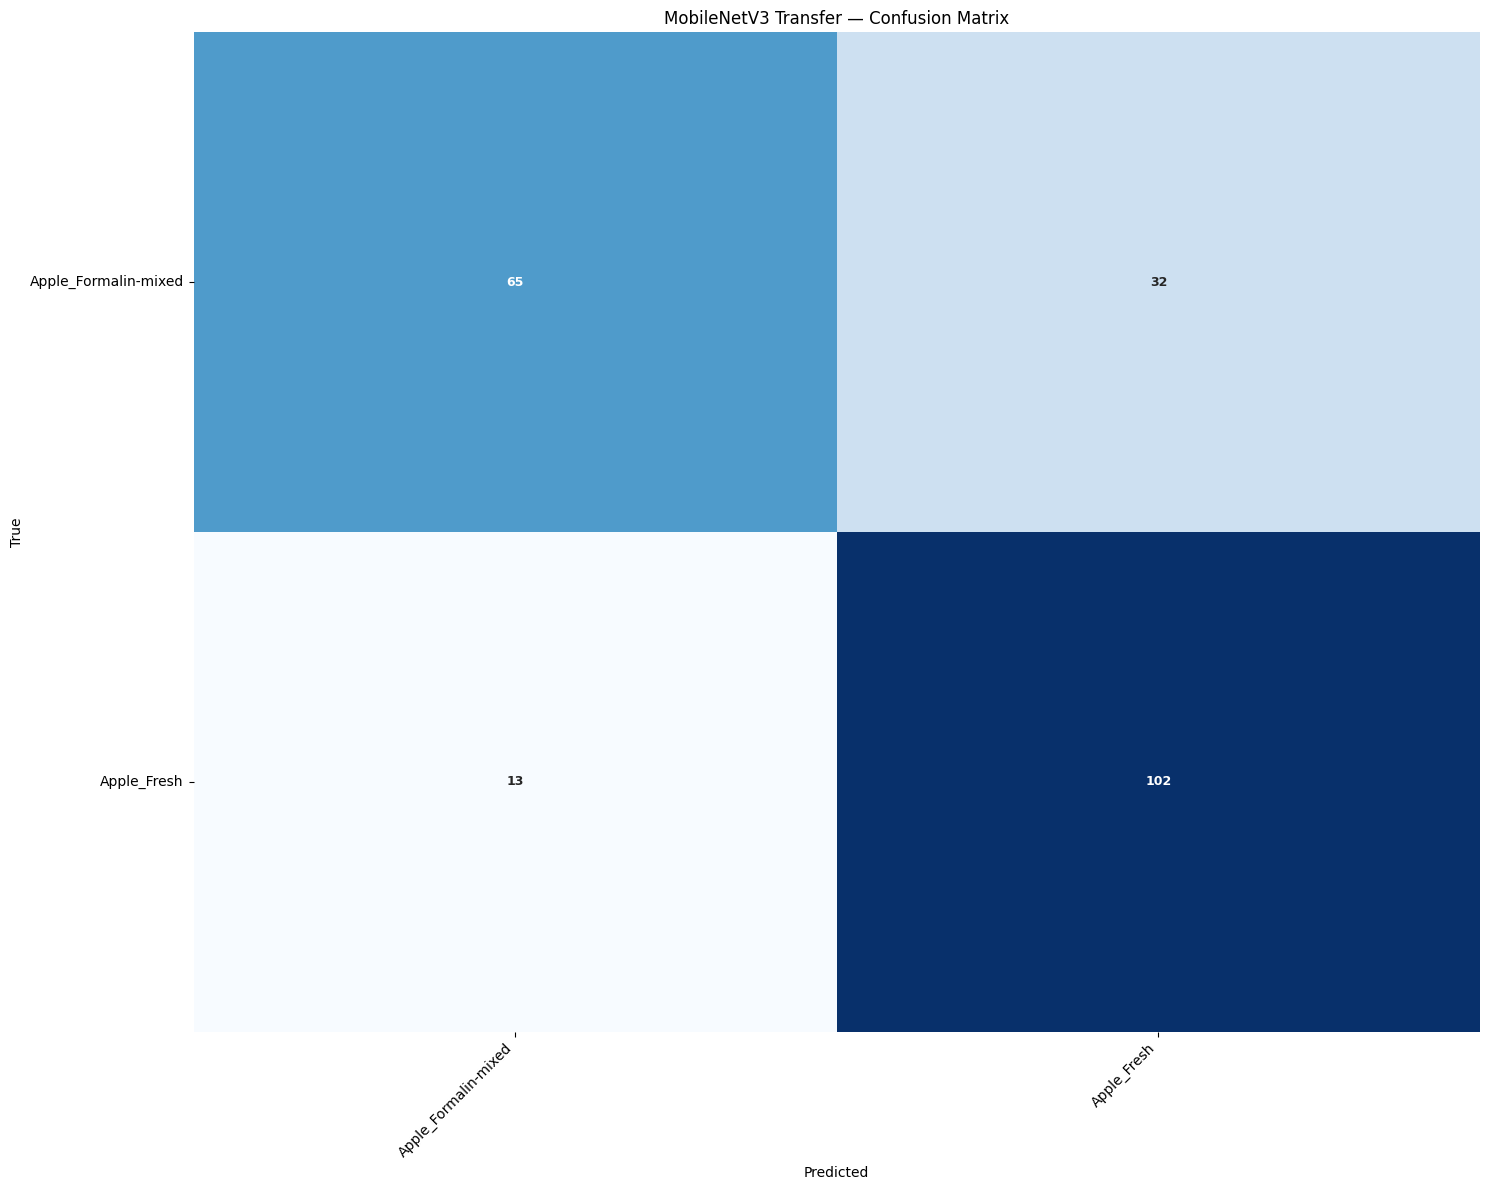

In [31]:
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names,
'MobileNetV3 Transfer')

### Fine-Tuning the Transfer Learning Model

In [32]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / \
{len(base_model.layers)}')

Trainable base layers after unfreezing: 30 / 157


In [33]:
FINETUNE_LR = TL_LR / 10
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)

In [34]:
ft_history = tl_model.fit(
train_dataset, validation_data=val_dataset, epochs=20,
callbacks=make_callbacks('tl_finetuned'), verbose=2,
)

Epoch 1/20
16/16 - 22s - 1s/step - accuracy: 0.6731 - loss: 0.7092 - val_accuracy: 0.7773 - val_loss: 0.4385 - learning_rate: 1.0000e-05
Epoch 2/20
16/16 - 1s - 69ms/step - accuracy: 0.6670 - loss: 0.6706 - val_accuracy: 0.7915 - val_loss: 0.4331 - learning_rate: 1.0000e-05
Epoch 3/20
16/16 - 1s - 33ms/step - accuracy: 0.6924 - loss: 0.6463 - val_accuracy: 0.7915 - val_loss: 0.4312 - learning_rate: 1.0000e-05
Epoch 4/20
16/16 - 1s - 39ms/step - accuracy: 0.6934 - loss: 0.6331 - val_accuracy: 0.7915 - val_loss: 0.4294 - learning_rate: 1.0000e-05
Epoch 5/20
16/16 - 1s - 33ms/step - accuracy: 0.6548 - loss: 0.6661 - val_accuracy: 0.7915 - val_loss: 0.4282 - learning_rate: 1.0000e-05
Epoch 6/20
16/16 - 1s - 33ms/step - accuracy: 0.6711 - loss: 0.6255 - val_accuracy: 0.7915 - val_loss: 0.4271 - learning_rate: 1.0000e-05
Epoch 7/20
16/16 - 1s - 32ms/step - accuracy: 0.6934 - loss: 0.6130 - val_accuracy: 0.7867 - val_loss: 0.4254 - learning_rate: 1.0000e-05
Epoch 8/20
16/16 - 1s - 34ms/step -

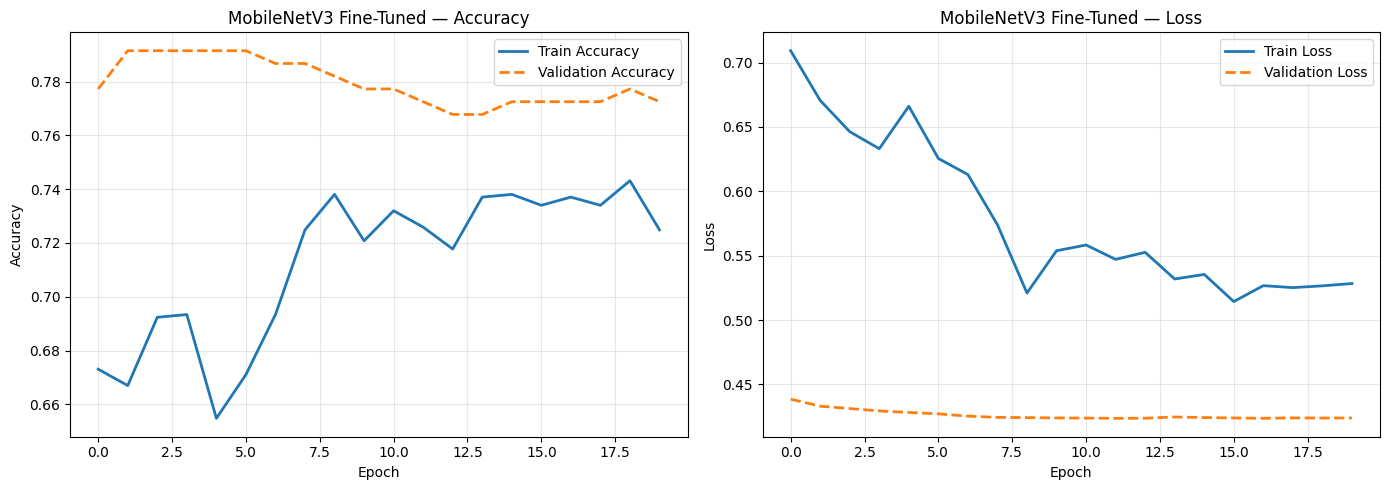

In [35]:
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')



MobileNetV3 Fine-Tuned
Accuracy : 0.8160
Precision : 0.8158
Recall : 0.8160
F1-Score : 0.8158

Classification Report:
                      precision    recall  f1-score   support

Apple_Formalin-mixed     0.8085    0.7835    0.7958        97
         Apple_Fresh     0.8220    0.8435    0.8326       115

            accuracy                         0.8160       212
           macro avg     0.8153    0.8135    0.8142       212
        weighted avg     0.8158    0.8160    0.8158       212



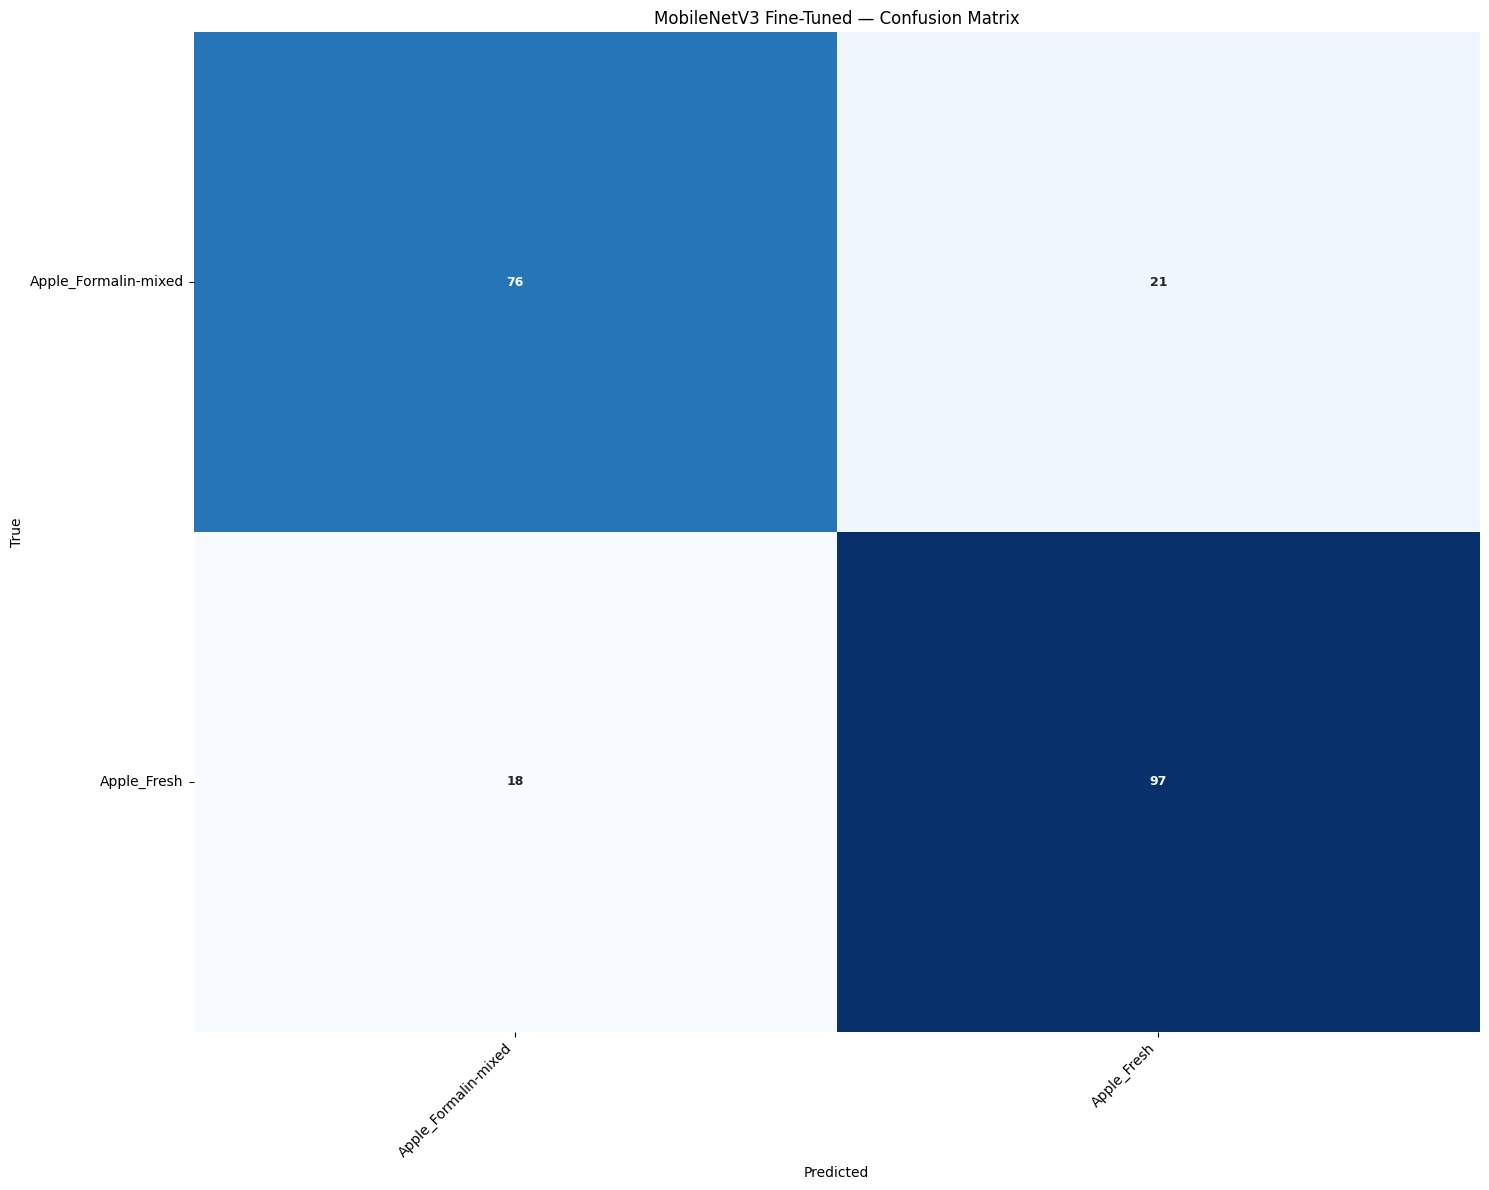

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.4575        322,338
MobileNetV3 (TL)              0.7877      1,087,346
MobileNetV3 (FT)              0.8160      1,087,346


In [36]:
ft_test_acc = evaluate_model(tl_model,
test_dataset, class_names, 'MobileNetV3 Fine-Tuned')
# STEP 35: Side-by-side model comparison. Compare all three models on validation accuracy and
# parameter count.
results = {
'Custom CNN': {'acc': cnn_test_acc, 'params': cnn_model.count_params()},
'MobileNetV3 (TL)': {'acc': tl_test_acc, 'params':
tl_model.count_params()}, 'MobileNetV3 (FT)': {'acc': ft_test_acc,
'params': tl_model.count_params()},}
print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

### Model Comparison and Prediction Demo

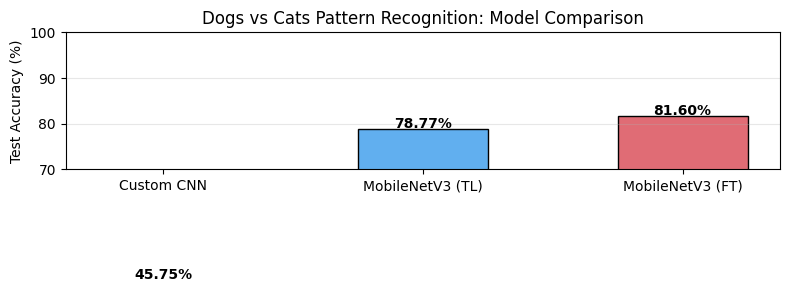

In [37]:
labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]
colors = ['#e06c75', '#61afef']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(70, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Dogs vs Cats Pattern Recognition: Model Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
    bar.get_height() + 0.3,
    f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [38]:
def predict_image(img_path, models_dict, class_names, image_size=(224,
224)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img) # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0) # (1, H, W, 3)
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()
    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        prob = mdl.predict(img_array, verbose=0)[0][0]
        label = class_names[int(prob >= 0.5)]
        print(f'{name:<25}: {label} (p={prob:.4f})')

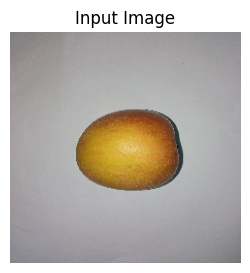


Predictions for: /content/extracted_applecontent/Apple/Fresh/msg5170347760-66136.jpg
----------------------------------------


Custom CNN               : Apple_Fresh (p=0.5648)
MobileNetV3 TL           : Apple_Formalin-mixed (p=0.4514)


In [39]:
# Update path to an image you want to test
predict_image(
    test_files[0], # Using the first image from the test set as an example
    {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
    class_names
)

### Save Trained Models

In [40]:
os.makedirs('models', exist_ok=True)
cnn_model.save('models/custom_cnn.keras')
tl_model.save('models/mobilenetv3_transfer.keras')
print('Models saved:')
print(' models/custom_cnn.keras')
print(' models/mobilenetv3_transfer.keras')

Models saved:
 models/custom_cnn.keras
 models/mobilenetv3_transfer.keras


## 3. Streamlit Frontend & Deployment

### Prepare Example Images for the Gallery

In [41]:
import os
import shutil
import random
import glob # Import glob

# Define the directory for gallery images
GALLERY_IMAGES_DIR = './gallery_images'
os.makedirs(GALLERY_IMAGES_DIR, exist_ok=True)

# Get a list of all image files in the test_dir
# The `test_dir` variable should be available from previous cells (e.g., d8f9e41f)
all_test_image_paths = []
# Assuming test_dir points to the root of your test images, e.g., '/content/datasets/applerenamed/test'
# We need to find images within its subdirectories (classes)
for class_sub_dir in os.listdir(test_dir):
    full_class_path = os.path.join(test_dir, class_sub_dir)
    if os.path.isdir(full_class_path):
        all_test_image_paths.extend(glob.glob(os.path.join(full_class_path, '*.jpg')))
        all_test_image_paths.extend(glob.glob(os.path.join(full_class_path, '*.png')))
        # Add other image extensions if necessary

if not all_test_image_paths:
    print(f"Warning: No images found in {test_dir} or its subdirectories for the gallery.")

# Randomly select a subset of images for the gallery
num_gallery_images = 15 # You can adjust this number
selected_gallery_paths = random.sample(all_test_image_paths, min(num_gallery_images, len(all_test_image_paths)))

# Clear existing gallery images to avoid duplicates and stale files
if os.path.exists(GALLERY_IMAGES_DIR):
    shutil.rmtree(GALLERY_IMAGES_DIR)
os.makedirs(GALLERY_IMAGES_DIR, exist_ok=True)

# Copy selected images to the gallery directory
print(f"Copying {len(selected_gallery_paths)} images to '{GALLERY_IMAGES_DIR}' for the Streamlit gallery...")
for src_path in selected_gallery_paths:
    shutil.copy(src_path, GALLERY_IMAGES_DIR)
print("Gallery images prepared.")

Copying 15 images to './gallery_images' for the Streamlit gallery...
Gallery images prepared.


### Streamlit Dependencies Installation

In [42]:
import sys
!{sys.executable} -m pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 128.3 MB/s eta 0:00:00


### Streamlit Application Code (`app.py`)

In [43]:
%%writefile app.py
import streamlit as st
from PIL import Image
import os
import random
import tensorflow as tf
import numpy as np
import glob

# --- Configuration Variables ---
# Adjust these paths if you move your app.py file
GALLERY_IMAGES_DIR = './gallery_images' # Directory containing sample images for the gallery
MODEL_PATH = 'models/mobilenetv3_transfer.keras' # Path to your trained model
EXTERNAL_IMAGE_LINK = 'https://www.google.com/search?q=apple+fruit+images&tbm=isch' # External link for more images
MODEL_TEST_ACCURACY = 81.60 # Placeholder: Replace with actual test accuracy from notebook evaluation
app_class_names = ['Apple_Formalin-mixed', 'Apple_Fresh'] # Explicitly define class names for the app

# --- Session State Initialization (for persistent gallery selection) ---
if 'selected_example_path' not in st.session_state:
    st.session_state.selected_example_path = None
if 'selected_example_image' not in st.session_state:
    st.session_state.selected_example_image = None
if 'example_prediction_results' not in st.session_state:
    st.session_state.example_prediction_results = None

# --- Load Model (Best Performing: MobileNetV3 Fine-Tuned) ---
try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception as e:
    st.error(f"Error loading model: {e}. Please ensure '{MODEL_PATH}' is available.")
    model = None # Set model to None if loading fails

# --- Prepare Test Files for Gallery ---
app_test_files = glob.glob(os.path.join(GALLERY_IMAGES_DIR, '*'))
if not app_test_files:
    st.warning(f"No images found in '{GALLERY_IMAGES_DIR}'. Please ensure this directory exists and contains images if you want to use the example gallery.")

# --- Prediction Function ---
def predict_image(image, model, class_names, image_size=(128, 128)):
    if model is None:
        return None, None, None, None # Indicate model not loaded

    img_resized = image.resize(image_size)
    img_array = tf.keras.utils.img_to_array(img_resized) # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0) # (1, H, W, 3)

    # The model was likely trained with MobileNetV3 preprocessing, which scales to [-1, 1]
    preprocessed_img = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

    predictions = model.predict(preprocessed_img)
    # Return the full softmax probabilities
    softmax_scores = tf.nn.softmax(predictions[0]).numpy()
    predicted_class_index = np.argmax(softmax_scores)
    predicted_class_name = class_names[predicted_class_index]
    confidence = softmax_scores[predicted_class_index] * 100
    return predicted_class_name, predicted_class_index, confidence, softmax_scores


# --- Streamlit UI ---
st.set_page_config(
    page_title="🍎 Apple Disease Classifier",
    layout="centered",
    initial_sidebar_state="auto",
    menu_items={
        'Get Help': 'https://www.extremely.cool-app.com/help', # Placeholder link
        'Report a bug': "https://www.extremely.cool-app.com/bug", # Placeholder link
        'About': "# This is a classifier for apple diseases."
    }
)

st.title("🍎 Apple Disease Classifier")
st.markdown("Upload an image of an apple to classify its health status (Formalin-mixed or Fresh).")
st.markdown("---")

# Section 1: Explore Example Images
st.subheader("1. Explore Example Images")

# Hyperlink to external images
st.markdown(
    f"""
    You can explore more apple images by visiting this [external image gallery]({EXTERNAL_IMAGE_LINK}).
    """
)

# Or choose from a library taken from the test part of the dataset
if app_test_files:
    st.markdown("---")
    st.markdown("**Alternatively, select an image from our internal gallery below:**")

    # Display a dropdown for selecting images
    example_image_basenames = [os.path.basename(path) for path in app_test_files]

    selected_example_basename = st.selectbox(
        "Choose an example image from the gallery:",
        ["Select an image"] + example_image_basenames,
        index=0
    )

    if selected_example_basename != "Select an image":
        selected_example_path = os.path.join(GALLERY_IMAGES_DIR, selected_example_basename)
        if os.path.exists(selected_example_path):
            st.session_state.selected_example_path = selected_example_path
            st.session_state.selected_example_image = Image.open(selected_example_path)
            st.session_state.example_prediction_results = None # Clear previous results
        else:
            st.error(f"Error: Selected example image not found at {selected_example_path}.")
else:
    st.info("No images available in '" + GALLERY_IMAGES_DIR + "' for the gallery. Please ensure this directory exists and contains images.")

# Display the selected example image if it's in session state
if st.session_state.selected_example_image:
    st.image(st.session_state.selected_example_image, caption=f"Selected Example: {os.path.basename(st.session_state.selected_example_path)}", width=None)

    if st.button("Classify Selected Example"):
        if model:
            _, _, _, softmax_scores = predict_image(st.session_state.selected_example_image, model, app_class_names, image_size=(128, 128))
            st.subheader("Prediction for Selected Example:")

            # Visual progress bars for confidence scores
            cols = st.columns(len(app_class_names))
            max_score_index = np.argmax(softmax_scores)

            for i, score in enumerate(softmax_scores):
                with cols[i]:
                    st.write(f"**{app_class_names[i]}**")
                    # Display a checkmark for the highest confidence class
                    display_value = f"{score * 100:.2f}% {'✅' if i == max_score_index else ''}"
                    st.progress(score)
                    st.write(display_value)

            st.session_state.example_prediction_results = softmax_scores # Store for persistence
        else:
            st.error("Model not loaded for prediction.")

# Display prediction results if available in session state (e.g., after rerun for persistence)
# This checks if there are results AND if an image isn't currently selected/displayed above
if st.session_state.example_prediction_results is not None and not st.session_state.selected_example_image:
    st.subheader("Last Prediction for Selected Example:")

    cols = st.columns(len(app_class_names))
    max_score_index = np.argmax(st.session_state.example_prediction_results)

    for i, score in enumerate(st.session_state.example_prediction_results):
        with cols[i]:
            st.write(f"**{app_class_names[i]}**")
            display_value = f"{score * 100:.2f}% {'✅' if i == max_score_index else ''}"
            st.progress(score)
            st.write(display_value)

st.markdown("---")

# Section 2: Upload Your Own Image
st.subheader("2. Upload Your Own Image")
st.markdown("Upload an image from your computer or use a camera if available.")

uploaded_file = st.file_uploader(
    "Choose an image file (JPG, JPEG, PNG, WEBP, GIF, BMP, TIFF)",
    type=["jpg", "jpeg", "png", "webp", "gif", "bmp", "tiff"],
    help="Drag and drop your image here or click to browse files. On mobile, this may allow camera access."
)

if uploaded_file is not None:
    try:
        image = Image.open(uploaded_file)
        st.image(image, caption="Uploaded Image", width=None)
        st.success("Image uploaded successfully!")

        if st.button("Classify Uploaded Image"):
            if model:
                _, _, _, softmax_scores = predict_image(image, model, app_class_names, image_size=(128, 128))
                st.subheader("Prediction for Uploaded Image:")

                cols = st.columns(len(app_class_names))
                max_score_index = np.argmax(softmax_scores)

                for i, score in enumerate(softmax_scores):
                    with cols[i]:
                        st.write(f"**{app_class_names[i]}**")
                        display_value = f"{score * 100:.2f}% {'✅' if i == max_score_index else ''}"
                        st.progress(score)
                        st.write(display_value)
            else:
                st.error("Model not loaded for prediction.")
    except Exception as e:
        st.error(f"Error loading image: {e}")
else:
    st.info("Awaiting image upload. Please upload a file to proceed with classification.")

st.markdown("---")

# Section 3: Model Performance Summary
st.subheader("3. Model Performance Summary")
st.markdown("Here's a brief overview of the model's performance on a separate test set:")

st.metric(label="Model Test Accuracy", value=f"{MODEL_TEST_ACCURACY:.2f}%")

if MODEL_TEST_ACCURACY > 80:
    st.success("This model shows good overall accuracy. Great job!")
elif MODEL_TEST_ACCURACY > 60:
    st.info("The model has decent accuracy, but there might be room for improvement.")
else:
    st.warning("The model's accuracy is relatively low. Consider further training or model adjustments.")

st.markdown("*(Note: This accuracy score is a static value provided for context. For a live assessment, you would need a more sophisticated evaluation setup.)*")

Writing app.py


### Create `requirements.txt`

In [44]:
import streamlit as st
from PIL import Image
import os
import random

# Assuming class_names and test_files are available from previous Colab cells
# If running as a standalone .py file, you'd need to define/load these:
try:
    # Attempt to use variables from Colab environment
    if 'class_names' in globals() and 'test_files' in globals():
        app_class_names = class_names
        app_test_files = test_files
    else:
        # Fallback for standalone script if variables aren't global
        app_class_names = ['Apple_Formalin-mixed', 'Apple_Fresh'] # Placeholder
        app_test_files = [] # Placeholder
        st.warning("`class_names` or `test_files` not found. Using placeholders. "
                   "Ensure your data loading and variable definitions are correctly set up for deployment.")
except NameError:
    app_class_names = ['Apple_Formalin-mixed', 'Apple_Fresh'] # Placeholder
    app_test_files = [] # Placeholder
    st.warning("`class_names` or `test_files` not found. Using placeholders. "
               "Ensure your data loading and variable definitions are correctly set up for deployment.")


# --- Streamlit UI ---
st.set_page_config(
    page_title="🍎 Apple Disease Classifier",
    layout="centered",
    initial_sidebar_state="auto",
    menu_items={
        'Get Help': 'https://www.extremely.cool-app.com/help', # Placeholder link
        'Report a bug': "https://www.extremely.cool-app.com/bug", # Placeholder link
        'About': "# This is a classifier for apple diseases."
    }
)

st.title("🍎 Apple Disease Classifier")
st.markdown("Upload an image of an apple to classify its health status (Formalin-mixed or Fresh).")
st.markdown("---")

# Section 1: Explore Example Images
st.subheader("1. Explore Example Images")

# Hyperlink to external images
st.markdown(
    """
    You can explore a collection of sample apple images used for classification
    by visiting this [external image gallery](https://www.google.com/search?q=apple+disease+images&tbm=isch).
    (Note: This link is a placeholder. You can replace it with your actual dataset gallery.)
    """
)

# Or choose from a library taken from the test part of the dataset
if app_test_files:
    st.write("---")
    st.markdown("Alternatively, select an image from our internal test dataset library below:")

    # Get a few random images from test_files for selection
    num_display_examples = min(10, len(app_test_files))
    if num_display_examples > 0:
        example_image_paths = random.sample(app_test_files, num_display_examples)
        example_image_basenames = [os.path.basename(path) for path in example_image_paths]

        selected_example_basename = st.selectbox(
            "Choose an example image from the test set:",
            ["Select an image"] + example_image_basenames,
            index=0
        )

        if selected_example_basename != "Select an image":
            # Find the full path for the selected basename
            selected_example_path = next((path for path in example_image_paths if os.path.basename(path) == selected_example_basename), None)
            if selected_example_path:
                st.image(selected_example_path, caption=f"Selected Example: {selected_example_basename}", use_column_width=True)
            else:
                st.error("Could not find the selected example image path.")
    else:
        st.info("No test images available to display as examples.")
else:
    st.info("No test image paths available to display examples from the dataset.")

st.markdown("---")

# Section 2: Upload Your Own Image
st.subheader("2. Upload Your Own Image")
st.markdown("Upload an image from your computer or use a camera if available.")

uploaded_file = st.file_uploader(
    "Choose an image file (JPG, JPEG, PNG)",
    type=["jpg", "jpeg", "png"],
    help="Drag and drop your image here or click to browse files."
)

if uploaded_file is not None:
    try:
        image = Image.open(uploaded_file)
        st.image(image, caption="Uploaded Image", use_column_width=True)
        st.success("Image uploaded successfully!")
        # Here, you would typically add a button to trigger classification
        # if st.button("Classify Uploaded Image"):
        #     # Call your model prediction function here
        #     st.write("Classifying...")
        #     pass # Placeholder for model prediction
    except Exception as e:
        st.error(f"Error loading image: {e}")
else:
    st.info("Awaiting image upload. Please upload a file to proceed with classification.")

# Mention camera input capability (Streamlit's native file_uploader doesn't directly open camera,
# but can integrate with device cameras if the browser allows it for file selection).
st.markdown(
    """
    **Note on Camera Input:** Streamlit's `st.file_uploader` primarily accesses your computer's files.
    For direct camera input in a web browser, you would typically need to integrate
    a custom Streamlit component (e.g., `streamlit_webrtc`) or deploy the app
    on a platform that allows direct camera access.
    """
)

2026-07-30 23:53:16.141 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:53:16.143 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:53:16.676 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-30 23:53:16.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:53:16.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:53:16.679 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-30 23:53:16.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

In [45]:
!pip install streamlit

In [46]:
%%writefile requirements.txt
streamlit
Pillow
tensorflow
numpy
scikit-learn
pandas

Writing requirements.txt


### Install pyngrok

In [47]:
# Install pyngrok to expose the Streamlit app to the internet
!pip install pyngrok

### Launch Streamlit App with ngrok

In [52]:
%%writefile app.py
import streamlit as st
from PIL import Image
import os
import random
import tensorflow as tf
import numpy as np
import glob

# --- Configuration Variables ---
# Adjust these paths if you move your app.py file
GALLERY_IMAGES_DIR = './gallery_images' # Directory containing sample images for the gallery
MODEL_PATH = 'models/mobilenetv3_transfer.keras' # Path to your trained model
EXTERNAL_IMAGE_LINK = 'https://www.google.com/search?q=apple+fruit+images&tbm=isch' # External link for more images
MODEL_TEST_ACCURACY = 81.60 # Placeholder: Replace with actual test accuracy from notebook evaluation
app_class_names = ['Apple_Formalin-mixed', 'Apple_Fresh'] # Explicitly define class names for the app

# --- Session State Initialization (for persistent gallery selection) ---
if 'selected_example_path' not in st.session_state:
    st.session_state.selected_example_path = None
if 'selected_example_image' not in st.session_state:
    st.session_state.selected_example_image = None
if 'example_prediction_results' not in st.session_state:
    st.session_state.example_prediction_results = None

# --- Load Model (Best Performing: MobileNetV3 Fine-Tuned) ---
try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception as e:
    st.error(f"Error loading model: {e}. Please ensure '{MODEL_PATH}' is available.")
    model = None # Set model to None if loading fails

# --- Prepare Test Files for Gallery ---
# This section is updated to correctly load images from GALLERY_IMAGES_DIR
app_test_files = glob.glob(os.path.join(GALLERY_IMAGES_DIR, '*'))
if not app_test_files:
    st.warning(f"No images found in '{GALLERY_IMAGES_DIR}'. Please ensure this directory exists and contains images if you want to use the example gallery.")

# --- Prediction Function ---
def predict_image(image, model, class_names, image_size=(128, 128)):
    if model is None:
        return None, None, None, None # Indicate model not loaded

    img_resized = image.resize(image_size)
    img_array = tf.keras.utils.img_to_array(img_resized) # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0) # (1, H, W, 3)

    # The model was likely trained with MobileNetV3 preprocessing, which scales to [-1, 1]
    preprocessed_img = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

    predictions = model.predict(preprocessed_img)
    # Return the full softmax probabilities
    softmax_scores = tf.nn.softmax(predictions[0]).numpy()
    predicted_class_index = np.argmax(softmax_scores)
    predicted_class_name = class_names[predicted_class_index]
    confidence = softmax_scores[predicted_class_index] * 100
    return predicted_class_name, predicted_class_index, confidence, softmax_scores


# --- Streamlit UI ---
st.set_page_config(
    page_title="🍎 Apple Disease Classifier",
    layout="centered",
    initial_sidebar_state="auto",
    menu_items={
        'Get Help': 'https://www.extremely.cool-app.com/help', # Placeholder link
        'Report a bug': "https://www.extremely.cool-app.com/bug", # Placeholder link
        'About': "# This is a classifier for apple diseases."
    }
)

st.title("🍎 Apple Disease Classifier")
st.markdown("Upload an image of an apple to classify its health status (Formalin-mixed or Fresh).")
st.markdown("---")

# Section 1: Explore Example Images
st.subheader("1. Explore Example Images")

# Hyperlink to external images
st.markdown(
    f"""
    You can explore more apple images by visiting this [external image gallery]({EXTERNAL_IMAGE_LINK}).
    """
)

# Or choose from a library taken from the test part of the dataset
if app_test_files:
    st.markdown("---")
    st.markdown("**Alternatively, select an image from our internal gallery below:**")

    # Display a dropdown for selecting images
    example_image_basenames = [os.path.basename(path) for path in app_test_files]

    selected_example_basename = st.selectbox(
        "Choose an example image from the gallery:",
        ["Select an image"] + example_image_basenames,
        index=0
    )

    if selected_example_basename != "Select an image":
        selected_example_path = os.path.join(GALLERY_IMAGES_DIR, selected_example_basename)
        if os.path.exists(selected_example_path):
            st.session_state.selected_example_path = selected_example_path
            st.session_state.selected_example_image = Image.open(selected_example_path)
            st.session_state.example_prediction_results = None # Clear previous results
        else:
            st.error(f"Error: Selected example image not found at {selected_example_path}.")
else:
    st.info("No images available in '" + GALLERY_IMAGES_DIR + "' for the gallery. Please ensure this directory exists and contains images.")

# Display the selected example image if it's in session state
if st.session_state.selected_example_image:
    st.image(st.session_state.selected_example_image, caption=f"Selected Example: {os.path.basename(st.session_state.selected_example_path)}", width='stretch')

    if st.button("Classify Selected Example"):
        if model:
            _, _, _, softmax_scores = predict_image(st.session_state.selected_example_image, model, app_class_names, image_size=(128, 128))
            st.subheader("Prediction for Selected Example:")

            # Visual progress bars for confidence scores
            cols = st.columns(len(app_class_names))
            max_score_index = np.argmax(softmax_scores)

            for i, score in enumerate(softmax_scores):
                with cols[i]:
                    st.write(f"**{app_class_names[i]}**")
                    # Display a checkmark for the highest confidence class
                    display_value = f"{score * 100:.2f}% {'✅' if i == max_score_index else ''}"
                    st.progress(float(score))
                    st.write(display_value)

            st.session_state.example_prediction_results = softmax_scores # Store for persistence
        else:
            st.error("Model not loaded for prediction.")

# Display prediction results if available in session state (e.g., after rerun for persistence)
# This checks if there are results AND if an image isn't currently selected/displayed above
if st.session_state.example_prediction_results is not None and not st.session_state.selected_example_image:
    st.subheader("Last Prediction for Selected Example:")

    cols = st.columns(len(app_class_names))
    max_score_index = np.argmax(st.session_state.example_prediction_results)

    for i, score in enumerate(st.session_state.example_prediction_results):
        with cols[i]:
            st.write(f"**{app_class_names[i]}**")
            display_value = f"{score * 100:.2f}% {'✅' if i == max_score_index else ''}"
            st.progress(float(score))
            st.write(display_value)

st.markdown("---")

# Section 2: Upload Your Own Image
st.subheader("2. Upload Your Own Image")
st.markdown("Upload an image from your computer or use a camera if available.")

uploaded_file = st.file_uploader(
    "Choose an image file (JPG, JPEG, PNG, WEBP, GIF, BMP, TIFF)",
    type=["jpg", "jpeg", "png", "webp", "gif", "bmp", "tiff"],
    help="Drag and drop your image here or click to browse files. On mobile, this may allow camera access."
)

if uploaded_file is not None:
    try:
        image = Image.open(uploaded_file)
        st.image(image, caption="Uploaded Image", width='stretch')
        st.success("Image uploaded successfully!")

        if st.button("Classify Uploaded Image"):
            if model:
                _, _, _, softmax_scores = predict_image(image, model, app_class_names, image_size=(128, 128))
                st.subheader("Prediction for Uploaded Image:")

                cols = st.columns(len(app_class_names))
                max_score_index = np.argmax(softmax_scores)

                for i, score in enumerate(softmax_scores):
                    with cols[i]:
                        st.write(f"**{app_class_names[i]}**")
                        display_value = f"{score * 100:.2f}% {'✅' if i == max_score_index else ''}"
                        st.progress(float(score))
                        st.write(display_value)
            else:
                st.error("Model not loaded for prediction.")
    except Exception as e:
        st.error(f"Error loading image: {e}")
else:
    st.info("Awaiting image upload. Please upload a file to proceed with classification.")

st.markdown("---")

# Section 3: Model Performance Summary
st.subheader("3. Model Performance Summary")
st.markdown("Here's a brief overview of the model's performance on a separate test set:")

st.metric(label="Model Test Accuracy", value=f"{MODEL_TEST_ACCURACY:.2f}%")

if MODEL_TEST_ACCURACY > 80:
    st.success("This model shows good overall accuracy. Great job!")
elif MODEL_TEST_ACCURACY > 60:
    st.info("The model has decent accuracy, but there might be room for improvement.")
else:
    st.warning("The model's accuracy is relatively low. Consider further training or model adjustments.")

st.markdown("*(Note: This accuracy score is a static value provided for context. For a live assessment, you would need a more sophisticated evaluation setup.)*")

Overwriting app.py


In [49]:
from pyngrok import ngrok
from google.colab import userdata
import os
import subprocess
import threading
import time

# Get ngrok authtoken from Colab Secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Define log file paths
STREAMLIT_OUT_LOG = 'streamlit_output.log'
STREAMLIT_ERR_LOG = 'streamlit_error.log'

# Function to kill processes on a given port
def kill_process_on_port(port):
    print(f"Attempting to kill any process on port {port}...")
    try:
        # Find processes listening on the port
        # Use 'lsof' for macOS/Linux or 'netstat -ano' for Windows
        # For Colab (Linux), lsof is appropriate
        command = ['lsof', '-i', f':{port}', '-t']
        process_ids = subprocess.check_output(command).decode().strip().split('\n')
        process_ids = [pid for pid in process_ids if pid]

        if process_ids:
            for pid in process_ids:
                print(f"  Killing process {pid} on port {port}.")
                subprocess.run(['kill', '-9', pid])
            print(f"Successfully cleared port {port}.")
        else:
            print(f"No processes found on port {port}.")
    except subprocess.CalledProcessError:
        print(f"No processes found or error executing lsof for port {port}.")
    except Exception as e:
        print(f"An error occurred while trying to clear port {port}: {e}")


if not NGROK_AUTH_TOKEN:
    print("Error: NGROK_AUTH_TOKEN not found in Colab Secrets.")
    print("Please add your ngrok authtoken to Colab Secrets (the '🔑' icon in the left panel) with the name 'NGROK_AUTH_TOKEN'.")
else:
    # Authenticate ngrok
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("ngrok authtoken set.")

    # Kill any existing ngrok tunnels
    ngrok.kill()

    # Ensure port 8501 is free before starting Streamlit
    kill_process_on_port(8501)

    # Start Streamlit in a separate thread
    def run_streamlit():
        command = ["streamlit", "run", "app.py", "--server.port", "8501", "--server.enableCORS", "False", "--server.enableXsrfProtection", "False"]

        # Redirect stdout and stderr to files
        with open(STREAMLIT_OUT_LOG, 'w') as out_file, open(STREAMLIT_ERR_LOG, 'w') as err_file:
            subprocess.Popen(command, stdout=out_file, stderr=err_file)

    print("Starting Streamlit app in background...")
    streamlit_thread = threading.Thread(target=run_streamlit)
    streamlit_thread.daemon = True # Allow main program to exit even if thread is still running
    streamlit_thread.start()

    # Give Streamlit a moment to start up
    time.sleep(10) # Increased sleep time to ensure logs are written

    # Open a ngrok tunnel to the Streamlit port (default 8501)
    try:
        public_url = ngrok.connect(addr="8501")
        print(f"Streamlit App URL: {public_url}")
        print("Click the link above to access your Streamlit app!")
        print("To stop the ngrok tunnel and Streamlit app, interrupt this cell's execution (Ctrl+C or stop button).")
    except Exception as e:
        print(f"Failed to start ngrok tunnel: {e}")
        print("Please ensure your NGROK_AUTH_TOKEN is correct and try again.")
    finally:
        # Print Streamlit logs regardless of ngrok success
        print("\n--- Streamlit Output Log ---")
        if os.path.exists(STREAMLIT_OUT_LOG):
            with open(STREAMLIT_OUT_LOG, 'r') as f:
                print(f.read())
        else:
            print("Streamlit output log file not found.")

        print("\n--- Streamlit Error Log ---")
        if os.path.exists(STREAMLIT_ERR_LOG):
            with open(STREAMLIT_ERR_LOG, 'r') as f:
                print(f.read())
        else:
            print("Streamlit error log file not found.")

ngrok authtoken set.
Attempting to kill any process on port 8501...
No processes found or error executing lsof for port 8501.
Starting Streamlit app in background...
Streamlit App URL: NgrokTunnel: "https://nerd-trading-squad.ngrok-free.dev" -> "http://localhost:8501"
Click the link above to access your Streamlit app!
To stop the ngrok tunnel and Streamlit app, interrupt this cell's execution (Ctrl+C or stop button).

--- Streamlit Output Log ---



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.66.130:8501



--- Streamlit Error Log ---
2026-07-30 23:53:52.465 Uvicorn server started on :::8501

